# Plotting Asteroid Orbits

#### This tutorial demonstrates how to fetch orbits from the MPC's Orbits API, build a REBOUND simulation, and plot the orbits of asteroids from several dynamical classes.

We will:
1. Fetch the orbits of eight well-known asteroids — near-Earth objects, main-belt asteroids, a Jupiter Trojan, and a Centaur — from the MPC Orbits API
2. Propagate them to a common epoch so their positions can be shown together
3. Build a [REBOUND](https://rebound.readthedocs.io/) simulation containing the Sun, the planets, and the asteroids
4. Make quick-look plots with REBOUND's built-in `OrbitPlot` and `OrbitPlotSet` tools
5. Build a custom, publication-style figure with orbits coloured by dynamical class

REBOUND comes with convenient built-in orbit plotting, so a quick visualisation is only one line of code; for full control we then draw our own figure directly with matplotlib.

Further information:
- [MPC Orbits API documentation](https://docs.minorplanetcenter.net/mpc-ops-docs/apis/get-orb/)
- [MPC Orbits API tutorial notebook](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_api_orbits/)
- [REBOUND documentation](https://rebound.readthedocs.io/)
- [Companion tutorial: From MPC Orbit to N-Body Simulation](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_rebound/)


## Environment Setup

This notebook requires `rebound`, `matplotlib`, `numpy`, and `requests`. We recommend creating a dedicated conda environment and registering it as a Jupyter kernel so that all dependencies are isolated and reproducible.

Run the following commands once in a terminal before opening this notebook:

```bash
# Create and populate the environment
conda create -n orbit-tutorial python=3.11 -y
conda activate orbit-tutorial
pip install rebound mpc-orb astropy matplotlib numpy requests ipykernel

# Register the environment as a Jupyter kernel
python -m ipykernel install --user --name orbit-tutorial --display-name "Python (orbit-tutorial)"
```

Then, in Jupyter, select **Kernel > Change Kernel > Python (orbit-tutorial)** before running the cells below.

If you already created the `orbit-tutorial` environment for the companion N-body tutorial, you can simply reuse it — no new packages are needed.


# Install and Import Packages

We need `requests` to talk to the MPC Orbits API, `rebound` to handle the orbits, and `numpy` / `matplotlib` for the custom figure.


In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt

import rebound


# Step 1: Fetch the Orbits

We select eight asteroids spanning four dynamical classes:

| Class | Objects |
|---|---|
| Near-Earth object (NEO) | Apophis, Eros, Phaethon |
| Main-belt asteroid | Ceres, Vesta, Pallas |
| Jupiter Trojan | Achilles |
| Centaur | Chiron |

The MPC Orbits API returns each orbit in the standardised [mpc_orb JSON format](https://docs.minorplanetcenter.net/mpc-ops-docs/orbits/mpc-orb-json/). We reuse the small `get_orbit` helper from the [Orbits API tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_api_orbits/) and read the JSON dictionaries directly.


In [2]:
# The objects we will plot, with their dynamical classes
ASTEROIDS = {
    "Apophis":  "NEO",
    "Eros":     "NEO",
    "Phaethon": "NEO",
    "Ceres":    "Main belt",
    "Vesta":    "Main belt",
    "Pallas":   "Main belt",
    "Achilles": "Jupiter Trojan",
    "Chiron":   "Centaur",
}

def get_orbit(designation):
    """Fetch the mpc_orb JSON dictionary for one object from the MPC Orbits API."""
    response = requests.get(
        "https://data.minorplanetcenter.net/api/get-orb",
        json={"desig": designation}
    )
    response.raise_for_status()
    result = response.json()
    if result and result[0].get("mpc_orb"):
        return result[0]["mpc_orb"][0]
    raise ValueError(f"No orbit returned for {designation!r}")

orbits = {}
print(f"{'Object':<10} {'Class':<15} {'Epoch (MJD, TT)':>16}")
print("-" * 43)
for name, cls in ASTEROIDS.items():
    orbits[name] = get_orbit(name)
    print(f"{name:<10} {cls:<15} {orbits[name]['epoch_data']['epoch']:>16.1f}")


Object     Class            Epoch (MJD, TT)
-------------------------------------------


Apophis    NEO                      60400.0


Eros       NEO                      61200.0


Phaethon   NEO                      61200.0


Ceres      Main belt                61000.0


Vesta      Main belt                61000.0


Pallas     Main belt                61200.0


Achilles   Jupiter Trojan           61200.0


Chiron     Centaur                  61200.0


# Step 2: Bring Everything to a Common Epoch

Notice that the epochs above **differ from object to object** (for example Apophis at MJD 60400.0, Ceres and Vesta at MJD 61000.0, and the rest at MJD 61200.0). Each orbit is an *osculating* solution valid at its own epoch.

For plotting the orbital *ellipses* this hardly matters — an osculating ellipse changes only very slowly. But we also want to mark **where each object is** along its orbit, and those position markers are only meaningful if every state vector refers to the same instant.

We therefore propagate each Cartesian state to the latest epoch in the set, MJD 61200.0, with a simple **two-body** (Sun + asteroid) REBOUND integration. The `CAR` coefficient values in the mpc_orb JSON are the heliocentric ecliptic position and velocity in AU and AU/day, so we set the simulation units to `('AU', 'day', 'Msun')` to match. Ignoring planetary perturbations over these gaps (at most 800 days) shifts the positions by far less than the resolution of our plots.


In [3]:
COMMON_EPOCH = 61200.0   # MJD (TT)

def state_at_common_epoch(mpc_orb, common_epoch_mjd):
    """Two-body propagate a Cartesian state vector to the common epoch.

    The mpc_orb 'CAR' coefficients are the heliocentric ecliptic
    position (AU) and velocity (AU/day) at the orbit's own epoch.
    """
    state = np.array(mpc_orb["CAR"]["coefficient_values"][:6])
    dt = common_epoch_mjd - mpc_orb["epoch_data"]["epoch"]   # days
    if dt == 0:
        return state
    s = rebound.Simulation()
    s.units = ("AU", "day", "Msun")     # match the MPC units
    s.add(m=1.0)                        # the Sun
    s.add(x=state[0], y=state[1], z=state[2],
          vx=state[3], vy=state[4], vz=state[5])
    s.integrate(dt)
    p = s.particles[1]
    return np.array([p.x, p.y, p.z, p.vx, p.vy, p.vz])

states = {name: state_at_common_epoch(orb, COMMON_EPOCH)
          for name, orb in orbits.items()}
print(f"All {len(states)} state vectors now refer to MJD {COMMON_EPOCH}")


All 8 state vectors now refer to MJD 61200.0


# Step 3: Build the Master Simulation

Now we build a single REBOUND simulation containing the Sun, the eight planets, and our eight asteroids, all at MJD 61200.0. REBOUND can load the Sun and planets directly from JPL Horizons by name.

Two details to be careful about:

- **Units and frames:** we set `sim.units = ('AU', 'day', 'Msun')` *before* adding any particles, so REBOUND matches the MPC units. REBOUND's Horizons interface returns *barycentric* ecliptic coordinates, while the MPC state vectors are *heliocentric* — so we add each asteroid's coordinates relative to the Sun particle.
- The `"Earth"` particle loaded from Horizons is actually the **Earth–Moon barycenter**, so do **not** also add the Moon as a separate body.

NB: It is possible that you may experience the following error when adding planets to REBOUND (which uses the NASA Horizons system to extract the planetary positions): `RuntimeError: An error occured while accessing NASA HORIZONS. If this is a SSL certificate issue, you can try disabling the certificate verification by setting rebound.horizons.SSL_CONTEXT = 'unverified'.`
 - In this scenario, the simplest approach is to just retry the evaluation, and this typically will succeed.


In [4]:
jd = COMMON_EPOCH + 2400000.5     # convert MJD -> JD for Horizons

sim = rebound.Simulation()
sim.units = ("AU", "day", "Msun")   # set BEFORE adding particles

planets = ["Sun", "Mercury", "Venus", "Earth", "Mars",
           "Jupiter", "Saturn", "Uranus", "Neptune"]
for body in planets:
    sim.add(body, date=f"JD{jd:.6f}")
    print(f"Added {body}")

# Horizons-loaded particles are barycentric; the MPC states are
# heliocentric, so add each asteroid relative to the Sun particle
sun = sim.particles[0]
for name in ASTEROIDS:
    st = states[name]
    sim.add(x=sun.x + st[0], y=sun.y + st[1], z=sun.z + st[2],
            vx=sun.vx + st[3], vy=sun.vy + st[4], vz=sun.vz + st[5])
print(f"Added {len(ASTEROIDS)} asteroids")

print(f"\nSimulation contains {sim.N} particles")


Searching NASA Horizons for 'Sun'... 


Found: Sun (10) 
Added Sun
Searching NASA Horizons for 'Mercury'... 


Found: Mercury Barycenter (199) (chosen from query 'Mercury')
Added Mercury
Searching NASA Horizons for 'Venus'... 


Found: Venus Barycenter (299) (chosen from query 'Venus')
Added Venus
Searching NASA Horizons for 'Earth'... 


Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Added Earth
Searching NASA Horizons for 'Mars'... 


Found: Mars Barycenter (4) (chosen from query 'Mars')
Added Mars
Searching NASA Horizons for 'Jupiter'... 


Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Added Jupiter
Searching NASA Horizons for 'Saturn'... 


Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Added Saturn
Searching NASA Horizons for 'Uranus'... 


Found: Uranus Barycenter (7) (chosen from query 'Uranus')
Added Uranus
Searching NASA Horizons for 'Neptune'... 


Found: Neptune Barycenter (8) (chosen from query 'Neptune')
Added Neptune
Added 8 asteroids

Simulation contains 17 particles


As a sanity check, let's convert each asteroid's state vector back into Keplerian elements with `particle.orbit(primary=sun)`. The values should look familiar: Phaethon's extreme eccentricity (e ≈ 0.89), Pallas's large inclination (i ≈ 35°), Achilles at Jupiter's semi-major axis (a ≈ 5.2 AU), and Chiron out among the giant planets (a ≈ 13.7 AU).


In [5]:
print(f"{'Object':<10} {'Class':<15} {'a (AU)':>8} {'e':>7} {'i (deg)':>8}")
print("-" * 52)
for k, (name, cls) in enumerate(ASTEROIDS.items()):
    o = sim.particles[len(planets) + k].orbit(primary=sun)
    print(f"{name:<10} {cls:<15} {o.a:>8.3f} {o.e:>7.3f} {np.degrees(o.inc):>8.2f}")


Object     Class             a (AU)       e  i (deg)
----------------------------------------------------
Apophis    NEO                0.923   0.191     3.34
Eros       NEO                1.458   0.223    10.83
Phaethon   NEO                1.271   0.890    22.31
Ceres      Main belt          2.766   0.080    10.59
Vesta      Main belt          2.362   0.090     7.14
Pallas     Main belt          2.770   0.231    34.93
Achilles   Jupiter Trojan     5.216   0.148    10.32
Chiron     Centaur           13.684   0.380     6.93


# Step 4: Quick Look with `rebound.OrbitPlot`

REBOUND's built-in [`OrbitPlot`](https://rebound.readthedocs.io/en/latest/plotting/) draws every orbit in the simulation with a single call. The returned object exposes the underlying matplotlib figure and axes as `.fig` and `.ax`, so you can customise or save the result afterwards.

Useful parameters include:

- `projection` — `"xy"` (top-down, the default), `"xz"`, or `"yz"` for edge-on views
- `particles` — a list of particle indices to plot (default: everything except the primary)
- `color` — `True` cycles a colour per orbit (you can also pass a list of colours)
- `orbit_style` — `"trail"` (fading, shows direction of motion), `"solid"`, or `"none"`
- `periastron` — mark each orbit's periastron

Plotting all 16 orbits at once compresses the inner Solar System into an unreadable blob at the centre, so here we use `particles=` to show only Mercury through Jupiter (indices 1–5) plus the NEOs and main-belt asteroids (indices 9–14).


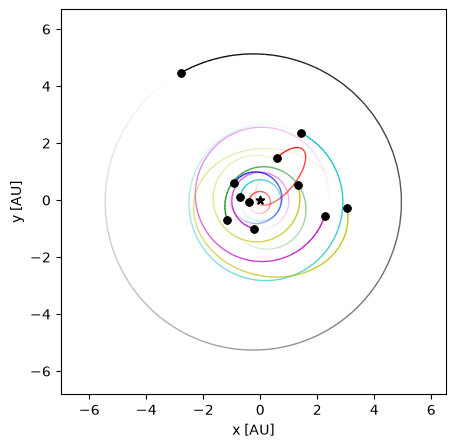

In [6]:
# Inner planets (1-5: Mercury..Jupiter) + inner asteroids (9-14: Apophis..Pallas)
inner = list(range(1, 6)) + list(range(9, 15))

op = rebound.OrbitPlot(sim, unitlabel="[AU]", color=True, particles=inner)


# Step 5: Three Projections with `rebound.OrbitPlotSet`

A top-down view hides the third dimension. `OrbitPlotSet` draws the same simulation in all three projections at once: the main panel is the familiar top-down (x, y) view, while the side panels show the (x, z) and (z, y) edge-on views.

This time we plot the **full** simulation, out to Neptune and Chiron. In the edge-on panels the inclined orbits stand out immediately — watch for Pallas and Chiron tilting well out of the ecliptic plane.


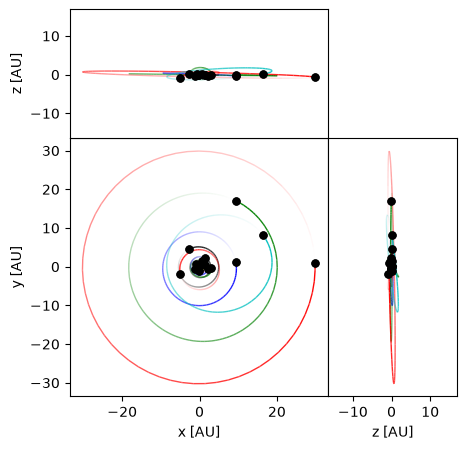

In [7]:
import logging
# OrbitPlotSet's equal-aspect axes trigger a harmless matplotlib notice
# ("Ignoring fixed x/y limits..."); silence that one logger
logging.getLogger("matplotlib.axes._base").setLevel(logging.ERROR)

ops = rebound.OrbitPlotSet(sim, unitlabel="[AU]", color=True)


# Step 6: A Custom Publication-Style Figure

The built-in plots are great for a quick look, but for a figure you would put in a talk or a paper you usually want full control: orbits coloured by *meaning* (here, dynamical class), planets drawn as recessive grey context, objects labelled directly, and chosen projections.

The key REBOUND tool is `particle.sample_orbit(Npts, primary=sun)`, which returns points along the particle's osculating orbit — we simply draw them with matplotlib.

We build two stacked panels: a top-down (x, y) view of the inner Solar System out to ±6.5 AU, and an edge-on (x, z) view beneath it. One design choice: **Chiron is excluded from this figure** — its 13.7 AU orbit lies entirely outside our frame (you already saw it in the `OrbitPlotSet` view above).


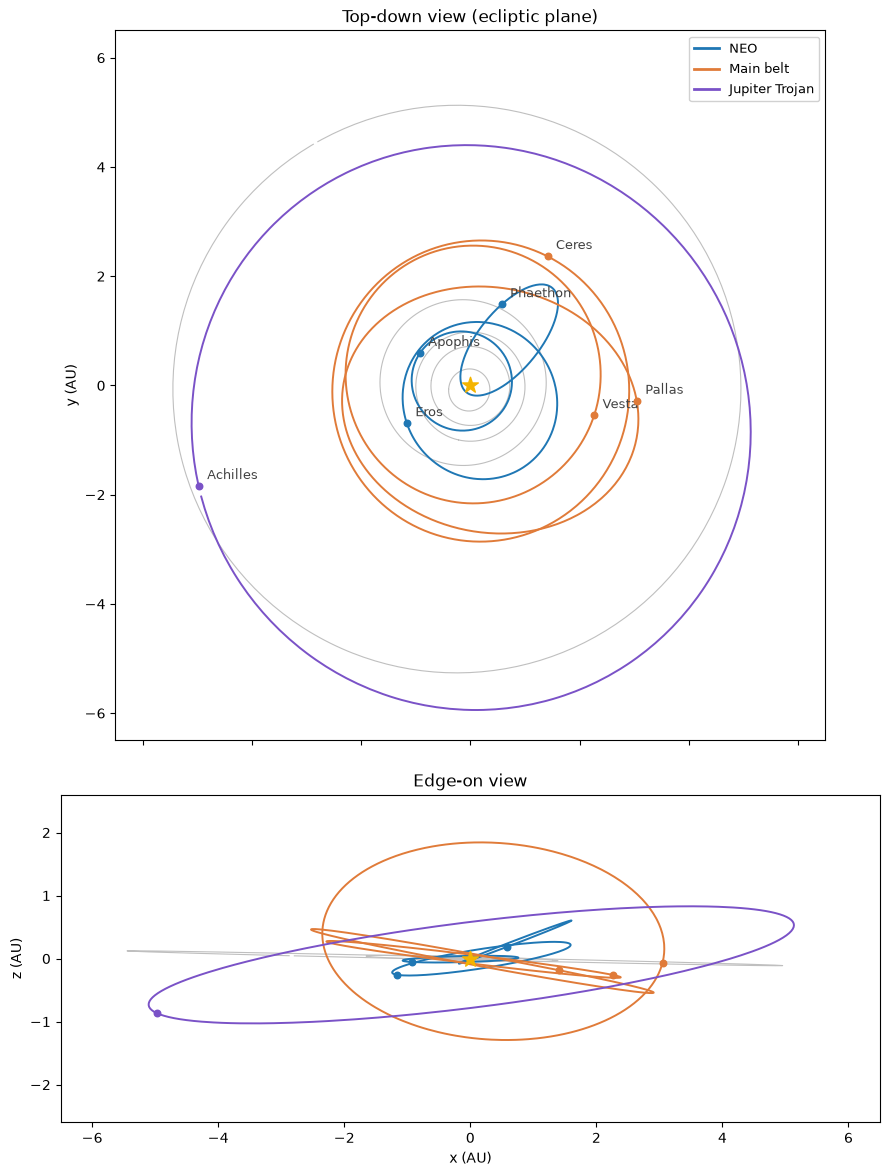

In [8]:
# Colour per dynamical class (Chiron/"Centaur" is out of frame and excluded)
CLASS_COLORS = {
    "NEO":            "#1f77b4",
    "Main belt":      "#e07b39",
    "Jupiter Trojan": "#7a52c7",
}

fig, (ax_xy, ax_xz) = plt.subplots(
    2, 1, figsize=(9, 12), height_ratios=[2, 1], sharex=True)

for ax, (ix, iy) in [(ax_xy, (0, 1)), (ax_xz, (0, 2))]:
    # Planets Mercury..Jupiter as recessive grey context
    for i in range(1, 6):
        pts = np.array(sim.particles[i].sample_orbit(Npts=300, primary=sun))
        ax.plot(pts[:, ix], pts[:, iy], color="0.75", lw=0.8, zorder=1)

    # Asteroids coloured by dynamical class, with a dot at the current position
    for k, (name, cls) in enumerate(ASTEROIDS.items()):
        if cls not in CLASS_COLORS:     # skip Chiron: out of frame
            continue
        p = sim.particles[len(planets) + k]
        color = CLASS_COLORS[cls]
        pts = np.array(p.sample_orbit(Npts=300, primary=sun))
        ax.plot(pts[:, ix], pts[:, iy], color=color, lw=1.4, zorder=2)
        rel = [p.x - sun.x, p.y - sun.y, p.z - sun.z]
        ax.scatter([rel[ix]], [rel[iy]], s=22, color=color, zorder=3)
        if ax is ax_xy:                 # direct labels in the top-down panel only
            ax.annotate(name, (rel[ix], rel[iy]), textcoords="offset points",
                        xytext=(6, 5), fontsize=9, color="0.25")

    ax.scatter([0], [0], marker="*", s=140, color="#f4b400", zorder=4)  # the Sun
    ax.set_aspect("equal")
    ax.set_xlim(-6.5, 6.5)

ax_xy.set_ylim(-6.5, 6.5)
ax_xz.set_ylim(-2.6, 2.6)
ax_xy.set_ylabel("y (AU)")
ax_xz.set_ylabel("z (AU)")
ax_xz.set_xlabel("x (AU)")
ax_xy.set_title("Top-down view (ecliptic plane)")
ax_xz.set_title("Edge-on view")

handles = [plt.Line2D([], [], color=c, lw=2, label=cls)
           for cls, c in CLASS_COLORS.items()]
ax_xy.legend(handles=handles, loc="upper right", fontsize=9, framealpha=0.9)
fig.tight_layout()
plt.show()


### Reading the figure

A few features worth noticing:

- **Phaethon** (e = 0.89) traces the long blue ellipse that dives *inside* Mercury's orbit at perihelion — this extreme orbit is why it is the parent body of the Geminid meteor shower.
- **Pallas** dominates the edge-on view: its 35° inclination carries it more than 2 AU above and below the ecliptic plane, while the other main-belt orbits stay comparatively flat.
- **Achilles** shares Jupiter's orbit at 5.2 AU — it is a Jupiter Trojan, librating around a point 60° ahead of the planet.
- The three **NEO** orbits all thread the tight cluster of grey terrestrial-planet orbits at the centre, which is exactly what makes them "near-Earth" objects.


# Going Further

Some ideas for building on this tutorial:

- **Animate the positions**: integrate the master simulation forward in small steps (`sim.integrate(t)`) and redraw the position markers at each step to watch the objects move along their orbits.
- **Colour by an orbital element**: instead of discrete classes, colour each orbit by a continuous quantity such as eccentricity or inclination using a sequential matplotlib colormap and a colorbar.
- **Plot thousands of orbits**: the [MPC data files](https://minorplanetcenter.net/data) provide orbital elements for the entire catalogue — the same `sample_orbit` technique scales up to density-style plots of whole populations.
- **Go interactive in 3D**: feed the `sample_orbit` points into plotly for a rotatable 3D view of the inclined orbits.
- **Propagate uncertainty**: the [companion N-body tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_rebound/) shows how to sample orbital clones from the covariance matrix and integrate them to visualise how orbital uncertainty evolves.

A further tutorial on ephemeris-quality integrations with ASSIST is in preparation.


# Summary

In this tutorial we:

1. **Fetched** the orbits of eight asteroids across four dynamical classes from the MPC Orbits API
2. **Propagated** each Cartesian state to a common epoch (MJD 61200.0) with simple two-body integrations, so the position markers are mutually consistent
3. **Built** a REBOUND simulation of the Sun, planets, and asteroids, taking care with units (AU, day, Msun) and with the heliocentric/barycentric distinction
4. **Plotted** quick-look views with `rebound.OrbitPlot` (selected particles, top-down) and `rebound.OrbitPlotSet` (all three projections)
5. **Designed** a custom two-panel matplotlib figure using `sample_orbit`, with orbits coloured by dynamical class and objects labelled directly

### Further Resources

- [MPC Orbits API documentation](https://docs.minorplanetcenter.net/mpc-ops-docs/apis/get-orb/)
- [MPC Orbits API tutorial notebook](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_api_orbits/)
- [REBOUND documentation](https://rebound.readthedocs.io/) and its [plotting guide](https://rebound.readthedocs.io/en/latest/plotting/)
- [Companion tutorial: From MPC Orbit to N-Body Simulation](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_rebound/)

For questions or feedback, contact the MPC via the [Jira Helpdesk](https://mpc-service.atlassian.net/servicedesk/customer/portal/13/create/148).
